In [35]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.utils import to_categorical, plot_model

import matplotlib.pyplot as plt
import numpy as np

import warnings
from warnings import filterwarnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)
filterwarnings('ignore')

In [36]:
#mnist veri setinin yüklenmesi
(x_train, y_train), (x_test, y_test) = mnist.load_data()

mnist veri setindeki veriler load_data() ve x_train setin ve x_test setleri olarak yükleniyor, labellar ise y_tarin ve y_test setleri olarak yükleniyor

60000 tane 28*28 pixel boyutunda train verisi var train label sayısı da 60000
10000 tane ise test verisi var bunlar da 28*28pixel boyutlarında

labellarımız aslında sınıflardır.burada 0-9 arasındaki sayıları sınıflandırmak istiyoruz bu yüzden 10 sınıfımız var.

In [38]:
print("test etiketleri boyutu:", y_train.shape)
print("unique test etiketleri:", np.unique(y_train))
print("unique test etiketleri sayısı:", len(np.unique(y_train)))

test etiketleri boyutu: (60000,)
unique test etiketleri: [0 1 2 3 4 5 6 7 8 9]
unique test etiketleri sayısı: 10


60000 tane label var ama unique 10 sınıf/label var

veri setini çalışma ortamına getirdik bir veriyi çalışma ortamında da görebilirz:

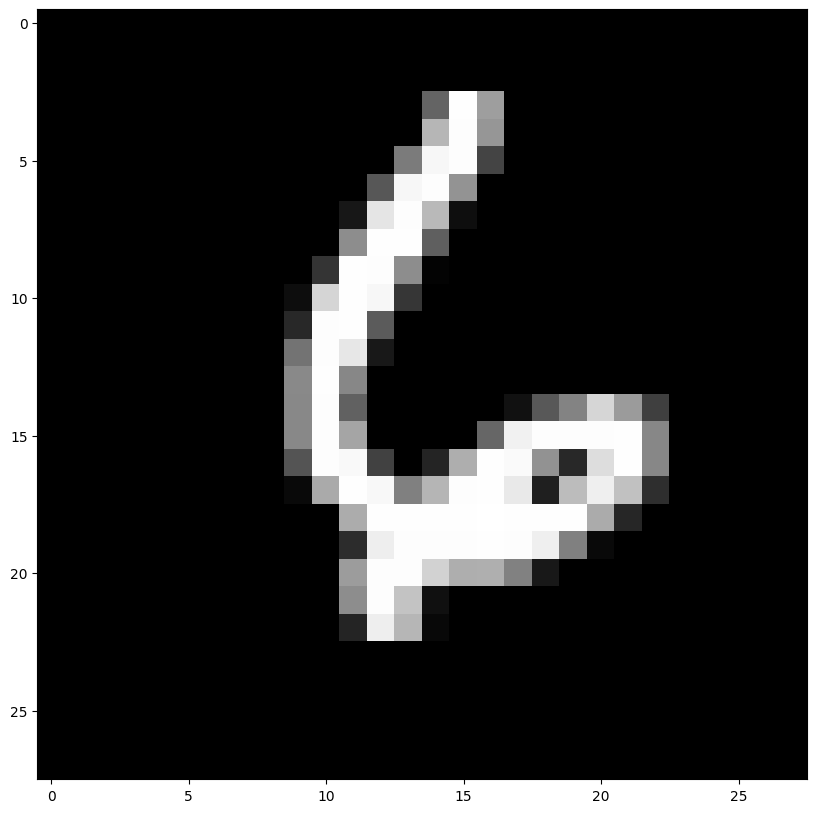

In [39]:
plt.figure(figsize=(10,10))    #gösterilecek görselin boyutları 10*10 olsun
plt.imshow(x_train[59000], cmap='gray')   #59000inci görsel gri tonlarında gösterilsin


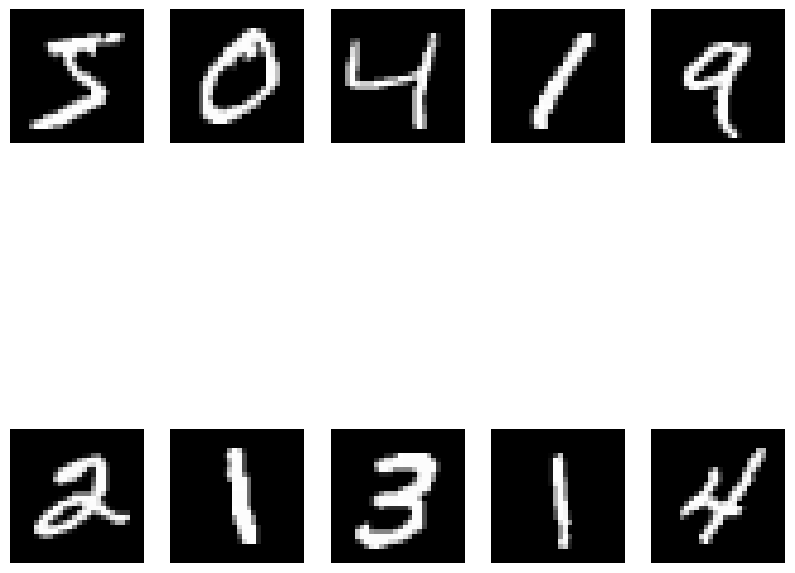

In [40]:
plt.figure(figsize=(10,10))
for i in range(10):
  ax = plt.subplot(2,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.axis('off')    #eksen bilgisi olmasın

**plt.subplot(2,5,i+1) ne yapar?**

# **plt.subplot(nrows, ncols, index)**

 fonksiyonu, bir figür (şekil) alanını alt grafiklere (subplot) bölmek için kullanılır.

2 → Satır sayısı (2 satır olacak)

5 → Sütun sayısı (her satırda 5 görüntü olacak)

i+1 → Kaçıncı alt grafiğe çizim yapılacağını belirtir (indeks 1’den başlar!)

Yani (2,5,i+1) demek:

“2 satır, 5 sütunluk bir ızgara oluştur ve i+1’inci kutuya çiz.”

Bu yüzden toplamda 2×5 = 10 grafik yerin olur.
Döngü for i in range(10) olduğu için 10 tane görüntü tam sığar ✅

💡 Neden (5,5,i+1) düzgün duruyor ama (1,5,i+1) hata veriyor?

(5,5,i+1) → 5 satır × 5 sütun = 25 yer var. Sen sadece ilk 10’unu dolduruyorsun, bu yüzden hata olmaz (ama boş kareler kalır).

(1,5,i+1) → 1 satır × 5 sütun = sadece 5 yer var. Döngü 10 defa çalıştığı için, i+1 altıncı olduğunda yer biter ve “index out of range” hatası alırsın ❌

In [41]:
#!! üstteki işlem iyi ve tekrar tekrar yazmamak için fonksiyonlaştırıyoruz
def visualize_img(data,n):
  plt.figure(figsize=(10,10))
  for i in range(n):
    ax = plt.subplot(5,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.axis('off')

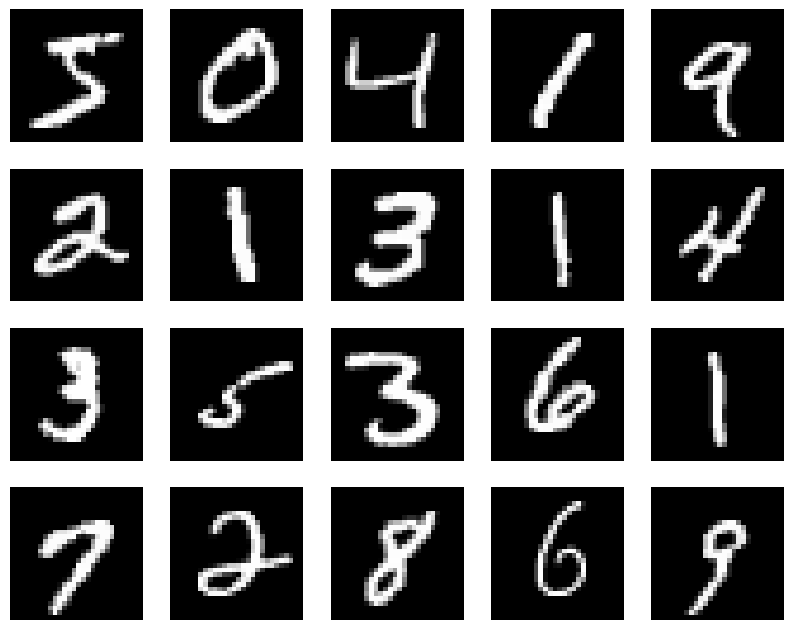

In [42]:
visualize_img(x_train,20)  #üstteki fonkla birlikte train veri setindeki 20 görsel 5 stün 5 satır olacak şekilde görselleştir

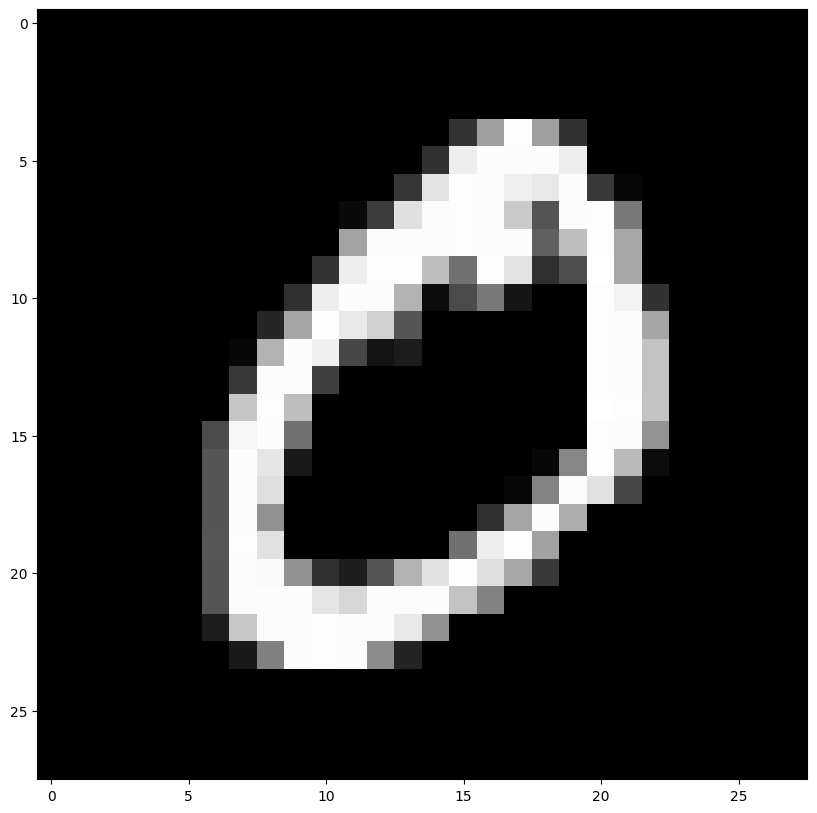

In [45]:
plt.figure(figsize=(10,10))    #gösterilecek görselin boyutları 10*10 olsun
plt.imshow(x_train[1], cmap='gray')   #59000inci görsel gri tonlarında gösterilsin


In [ ]:
#RGB (0-255)
# r:250 g:10 b:240 mor
# r:250 g:0 b:250 mor, daha koyu bir mor olur.

In [46]:
x_train[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         54, 227, 253, 252, 239, 233, 252,  57,   6,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  10,  60,
        224, 252, 253, 252, 202,  84, 252, 253, 122,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 163, 252,
        252, 252, 253, 252, 252,  96, 189, 253, 167,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  51, 238, 253,
        253, 190, 114, 253, 228,  47,  79, 255, 168,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  48, 238, 252, 252,
        179,  12,  75, 121,  21,   0,   0, 253, 243,  50,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  38, 165, 253, 233, 208,
         84,   0,   0,   0,   0,   0,   0, 253, 252, 165,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   7, 178, 252, 240,  71,  19,
         28,   0,   0,   0,   0,   0,   0, 253, 252, 195,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  57, 252, 252,  63,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 253, 252, 195,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 198, 253, 190,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 255, 253, 196,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  76, 246, 252, 112,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 253, 252, 148,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 230,  25,   0,   0,   0,
          0,   0,   0,   0,   0,   7, 135, 253, 186,  12,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 223,   0,   0,   0,   0,
          0,   0,   0,   0,   7, 131, 252, 225,  71,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 145,   0,   0,   0,   0,
          0,   0,   0,  48, 165, 252, 173,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  86, 253, 225,   0,   0,   0,   0,
          0,   0, 114, 238, 253, 162,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 249, 146,  48,  29,  85,
        178, 225, 253, 223, 167,  56,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 252, 252, 229, 215, 252,
        252, 252, 196, 130,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  28, 199, 252, 252, 253, 252, 252,
        233, 145,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  25, 128, 252, 253, 252, 141,
         37,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

!! bu sıfır görselinin numeric(numpy)halidir. aslında görseller bu şekilde matrisler halinde yüklenir bize gösterilirken figure hline çeviririz. 28 satır 28 sütundan oluşan bir array var (shapi 28,28) burada ve her eleman bir hücreyi temsil ediyor. eğer 0sa siyah 255 ise beyaz.

aynı zamanda numpy ile bir alanı seçip oranın ortalamasını alabiliriz.

In [50]:
 #mnset datasetindeki 2.görselin 10.satır 10.sütundaki pixeli (rgb) değerini getir
x_train[1][10,10]

np.uint8(238)

In [49]:
x_train[1] [3,5]

np.uint8(0)

In [51]:
x_train[1].mean()  #x_train[1] bir numpy array bunun ortalamsını alıyoruz
#!!yani bu görseller üzerinde matematiksel işlemler yapılabilir

np.float64(39.661989795918366)

In [52]:
x_train[1][15:20, 3:8]

array([[  0,   0,   0,  76, 246],
       [  0,   0,   0,  85, 252],
       [  0,   0,   0,  85, 252],
       [  0,   0,   0,  85, 252],
       [  0,   0,   0,  86, 253]], dtype=uint8)

In [54]:
x_train[1][15:20, 3:8]    #2.görselin numpy arrayinde bir alan seçiyoruz

array([[  0,   0,   0,  76, 246],
       [  0,   0,   0,  85, 252],
       [  0,   0,   0,  85, 252],
       [  0,   0,   0,  85, 252],
       [  0,   0,   0,  86, 253]], dtype=uint8)

In [53]:
x_train[1][15:20, 3:8].mean()  #seçtiğimiz alanın ortalamsını alıyoruz

np.float64(66.88)

In [64]:
#Bir gri tonlamalı (grayscale) görüntüyü alır ve
#her pikselin sayısal değerini (0–255 veya 0–1 arası) görselin üstüne yazar.

def pixel_visualize(img):
  fig = plt.figure(figsize=(10,10))
  ax = fig.add_subplot(111)  #add_subplot(111) → Tek bir alt grafik oluşturur (1 satır, 1 sütun, 1. grafik).
  ax.imshow(img, cmap='gray')
  width, height = img.shape

  threshold = img.max()/2.5

  for x in range(width):
    for y in range(height):
        ax.annotate(str(round(img[x,y],2)), xy=(y,x),
                    color='white' if img[x][y]<threshold else 'black')

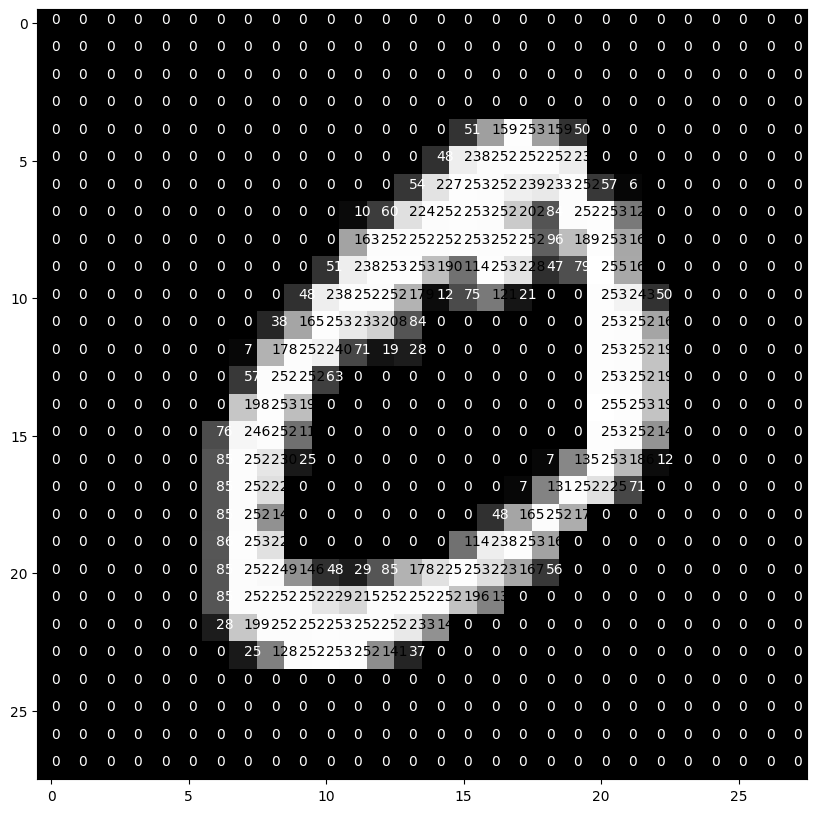

In [65]:
pixel_visualize(x_train[1])

threshold = img.max()/2.5
Piksel değerlerinin yarıdan biraz daha düşük bir eşiğini (threshold) hesaplar.

Bu, yazının rengi için kullanılır — yani parlak piksellerde siyah yazı, koyu piksellerde beyaz yazı gözüksün diye.